# 02b -- Fine-tuning TinyUSFM na syntetycznym datasecie AFAST (psy/koty)

**Projekt:** AI-asystowana nawigacja USG -- Vet Eye S.A. (BiznesAI 15, Akademia Leona Kozminskiego)

**Cel notebooka:** Wytrenowac view classifier na 4 klasach syntetycznego protokolu AFAST
(CC, DH, HR, SR) uzywajac pretrained backbone TinyUSFM (5.5M params, ViT-Tiny).

**Dwuetapowy trening (transfer learning):**
1. **Iteracja 1 (warm-up / linear probing):** zamrozony backbone, trenujemy TYLKO glowice klasyfikacyjna. Cel: glowica uczy sie rozsadnych wag w przestrzeni pretrained features.
2. **Iteracja 2 (partial unfreezing):** odmrazamy N ostatnich blokow transformera + glowica. Cel: backbone delikatnie dostosowuje sie do nowej domeny.

**Dlaczego dwa etapy?** Zweryfikowane empirycznie 15.05.2026: pominiecie warm-up'u (skok od razu do partial unfreezing z losowa glowica) powoduje catastrophic forgetting -- overfit w 2 epoki. Warm-up stabilizuje trening.

**Dataset:** [`koscielnamarta/synthetic-usg-afast-vet`](https://huggingface.co/datasets/koscielnamarta/synthetic-usg-afast-vet) -- 4000 syntetycznych obrazow USG (256x256 grayscale, zbalansowane 4 klasy).

**Backbone:** [TinyUSFM](https://github.com/MacDunno/TinyUSFM) -- ViT-Tiny pretrained na 2 mln obrazow USG.

## 0. Instalacja i importy

In [38]:
# Instalacja pakietow (Colab ma wiekszosci, ale upewniamy sie o wersje)
# WAZNE: timm==0.5.4 -- TinyUSFM wymaga dokladnie tej wersji (nowsze lamia import)
!pip install -q --upgrade huggingface_hub
!pip install -q timm==0.5.4
!pip install -q gdown scikit-learn

In [39]:
import os
import sys
import json
import time
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image, ImageFilter

# Sprawdzenie GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("UWAGA: brak GPU. Trening potrwa dluzej, ale zadziala.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Konfiguracja eksperymentu

In [40]:
# ====================================================================
# JEDYNE MIEJSCE GDZIE ZMIENIASZ PARAMETRY MIEDZY EKSPERYMENTAMI
# ====================================================================

# --- Identyfikacja HF ---
HF_USER = "koscielnamarta"
DATASET_REPO = f"{HF_USER}/synthetic-usg-afast-vet"
MODEL_REPO   = f"{HF_USER}/synthetic-usg-afast-vet-classifier"

# --- Parametry treningu ---
NUM_CLASSES = 4                  # CC, DH, HR, SR
IMG_SIZE    = 224                # TinyUSFM wymaga 224x224
BATCH_SIZE  = 32

# Iteracja 1 (warm-up / linear probing):
I1_EPOCHS = 5
I1_LR     = 1e-3                # wyzszy LR bo trenujemy tylko glowice

# Iteracja 2 (partial unfreezing):
I2_EPOCHS = 8
I2_LR     = 1e-4                # 10x nizszy -- delikatny fine-tuning backbone
NUM_UNFROZEN_BLOCKS = 1          # ile ostatnich blokow transformera odmrazamy
                                 # Finalna konfiguracja: blok 11 (ostatni). Wyniki dla 2 bloków zbliżone,
                                 # ale wyższy overfit. Szczegóły w sekcji 9.

WEIGHT_DECAY = 1e-4

# --- Foldery wynikowe (sesyjne -- po treningu pushujemy na HF) ---
RUN_NAME = f"I2_unfreeze{NUM_UNFROZEN_BLOCKS}blocks"
RUN_DIR  = f"/content/run_02b_{RUN_NAME}"
CKPT_DIR = f"{RUN_DIR}/checkpoints"
OUT_DIR  = f"{RUN_DIR}/outputs"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("=== Konfiguracja ===")
print(f"Dataset:   {DATASET_REPO}")
print(f"Model:     {MODEL_REPO}")
print(f"I1:        {I1_EPOCHS} epok, lr={I1_LR} (head only)")
print(f"I2:        {I2_EPOCHS} epok, lr={I2_LR} (+ {NUM_UNFROZEN_BLOCKS} blokow)")
print(f"Run dir:   {RUN_DIR}")

=== Konfiguracja ===
Dataset:   koscielnamarta/synthetic-usg-afast-vet
Model:     koscielnamarta/synthetic-usg-afast-vet-classifier
I1:        5 epok, lr=0.001 (head only)
I2:        8 epok, lr=0.0001 (+ 1 blokow)
Run dir:   /content/run_02b_I2_unfreeze1blocks


## 2. Pobranie datasetu z Hugging Face

In [41]:
from huggingface_hub import snapshot_download

print(f"Pobieram dataset: {DATASET_REPO}")
DATA_ROOT = snapshot_download(repo_id=DATASET_REPO, repo_type="dataset")
print(f"  -> {DATA_ROOT}")

# Cztery splity (train/val/holdout_easy/holdout_hard)
TRAIN_DIR        = os.path.join(DATA_ROOT, "dataset", "train")
VAL_DIR          = os.path.join(DATA_ROOT, "dataset", "test")                     # historyczna nazwa, funkcja = val
HOLDOUT_DIR      = os.path.join(DATA_ROOT, "dataset", "holdout")                  # pierwszy hold-out (latwiejszy, seed=123)
HOLDOUT_HARD_DIR = os.path.join(DATA_ROOT, "dataset", "synthetic_hard_holdout")   # drugi hold-out (trudniejszy)

for name, path in [("train", TRAIN_DIR), ("val", VAL_DIR),
                   ("holdout_easy", HOLDOUT_DIR), ("holdout_hard", HOLDOUT_HARD_DIR)]:
    assert os.path.exists(path), f"Brak splitu '{name}' w {path}"

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR)
                  if os.path.isdir(os.path.join(TRAIN_DIR, d))])
assert len(CLASSES) == NUM_CLASSES

print(f"\nKlasy ({len(CLASSES)}): {CLASSES}\n")
for name, path in [("train", TRAIN_DIR), ("val", VAL_DIR),
                   ("holdout_easy", HOLDOUT_DIR), ("holdout_hard", HOLDOUT_HARD_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, c))) for c in CLASSES)
    print(f"{name:14s}: {total} obrazow ({total // len(CLASSES)}/klasa)")

Pobieram dataset: koscielnamarta/synthetic-usg-afast-vet


Fetching ... files: 0it [00:00, ?it/s]

  -> /root/.cache/huggingface/hub/datasets--koscielnamarta--synthetic-usg-afast-vet/snapshots/263d42de5eb520ebad2f2e35cb87a28bedb3150c

Klasy (4): ['CC', 'DH', 'HR', 'SR']

train         : 3200 obrazow (800/klasa)
val           : 800 obrazow (200/klasa)
holdout_easy  : 800 obrazow (200/klasa)
holdout_hard  : 800 obrazow (200/klasa)


## 3. Pobranie modelu TinyUSFM

In [42]:
TINYUSFM_DIR = "/content/TinyUSFM"
CKPT_FILE    = "/content/tinyusfm_pretrained.pth"

if not os.path.exists(TINYUSFM_DIR):
    !git clone https://github.com/MacDunno/TinyUSFM.git {TINYUSFM_DIR}
    print("Repo TinyUSFM sklonowane")
else:
    print(f"Repo juz istnieje: {TINYUSFM_DIR}")

if not os.path.exists(CKPT_FILE):
    import gdown
    gdown.download(id="1P_wDuU-StALLJEBaymioaYu52CScW-l-", output=CKPT_FILE, quiet=False)
    print(f"Checkpoint pobrany: {os.path.getsize(CKPT_FILE) / 1e6:.1f} MB")
else:
    print(f"Checkpoint juz istnieje: {os.path.getsize(CKPT_FILE) / 1e6:.1f} MB")

if TINYUSFM_DIR not in sys.path:
    sys.path.insert(0, TINYUSFM_DIR)

Repo juz istnieje: /content/TinyUSFM
Checkpoint juz istnieje: 22.1 MB


In [43]:
from model.tinyusfm import TinyUSFM

model = TinyUSFM()
state_dict = torch.load(CKPT_FILE, map_location="cpu")
model.load_state_dict(state_dict, strict=False)

# TinyUSFM to wrapper — prawdziwy VisionTransformer siedzi w model.model
# Definiujemy alias "vit" zeby reszta notebooka byla czytelna
vit = model.model

# Diagnostyka — co ma VisionTransformer w srodku?
print("VisionTransformer children:")
for name, mod in vit.named_children():
    params = sum(p.numel() for p in mod.parameters())
    print(f"  {name:20s} {type(mod).__name__:25s} params={params:,}")

# Podmiana glowicy na NUM_CLASSES klas
# timm VisionTransformer z num_classes=0 ma head=Identity (brak parametrow)
# Podmieniamy na Linear(embed_dim, NUM_CLASSES)
embed_dim = vit.norm.normalized_shape[0]  # = 192 (hidden_dim ViT-Tiny)
vit.head = nn.Linear(embed_dim, NUM_CLASSES)
print(f"\nGlowica podmieniona: Linear({embed_dim} -> {NUM_CLASSES})")

model = model.to(device)

# Test forward pass — czy model zwraca logity o wlasciwym ksztalcie?
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}")
assert out.shape == (1, NUM_CLASSES), f"Oczekiwano (1, {NUM_CLASSES}), dostano {out.shape}"
print("Forward pass OK!")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: TinyUSFM (ViT-Tiny)")
print(f"Parametry lacznie: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Bloki transformera: {len(vit.blocks)} (indeksy 0..{len(vit.blocks)-1})")

VisionTransformer children:
  patch_embed          PatchEmbed                params=147,648
  pos_drop             Dropout                   params=0
  blocks               Sequential                params=5,338,368
  norm                 LayerNorm                 params=384
  pre_logits           Identity                  params=0
  head                 Identity                  params=0

Glowica podmieniona: Linear(192 -> 4)
Output shape: torch.Size([1, 4])
Forward pass OK!

Model: TinyUSFM (ViT-Tiny)
Parametry lacznie: 5,525,188 (5.5M)
Bloki transformera: 12 (indeksy 0..11)


## 4. Data loading (ImageFolder + augmentacje)

In [44]:
import torch
from torchvision import transforms

class AddSpeckleNoise:
    """
    Multiplikatywny szum typu speckle.
    Działa na tensorze po ToTensor(), przed Normalize().
    """
    def __init__(self, p=0.55, scale_min=0.05, scale_max=0.16):
        self.p = p
        self.scale_min = scale_min
        self.scale_max = scale_max

    def __call__(self, x):
        if torch.rand(1).item() > self.p:
            return x

        scale = torch.empty(1).uniform_(self.scale_min, self.scale_max).item()
        noise = torch.randn_like(x) * scale

        # multiplicative-ish noise: mocniej wpływa na jasne struktury
        x = x + x * noise
        return torch.clamp(x, 0.0, 1.0)


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
        shear=5,
        fill=0
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.30
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))
    ], p=0.35),

    transforms.ToTensor(),

    AddSpeckleNoise(
        p=0.55,
        scale_min=0.05,
        scale_max=0.16
    ),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3),
        value="random"
    ),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset        = ImageFolder(TRAIN_DIR,        transform=train_transform)
val_dataset          = ImageFolder(VAL_DIR,          transform=eval_transform)
holdout_dataset      = ImageFolder(HOLDOUT_DIR,      transform=eval_transform)
holdout_hard_dataset = ImageFolder(HOLDOUT_HARD_DIR, transform=eval_transform)

train_loader        = DataLoader(train_dataset,        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader          = DataLoader(val_dataset,          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
holdout_loader      = DataLoader(holdout_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
holdout_hard_loader = DataLoader(holdout_hard_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train:        {len(train_dataset)} obrazow")
print(f"Val:          {len(val_dataset)} obrazow")
print(f"Holdout easy: {len(holdout_dataset)} obrazow")
print(f"Holdout hard: {len(holdout_hard_dataset)} obrazow  <- trudniejszy, OOD-like")

Train:        3200 obrazow
Val:          800 obrazow
Holdout easy: 800 obrazow
Holdout hard: 800 obrazow  <- trudniejszy, OOD-like


## 5. Funkcje treningowe (reuzywane w I1 i I2)

In [45]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        running_loss += loss.item() * imgs.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return {
        'loss': running_loss / total,
        'acc': correct / total,
        'preds': np.array(all_preds),
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
    }


def run_training(model, train_loader, val_loader, criterion, optimizer,
                 epochs, device, ckpt_path, iteration_name="", scheduler=None):
    """Trening z early stopping na val_loader + opcjonalny LR scheduler."""
    best_val_acc = 0.0
    best_eval = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}  # +lr w history

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  {iteration_name}")
    print(f"  Epoki: {epochs} | LR start: {optimizer.param_groups[0]['lr']}")
    if scheduler is not None:
        print(f"  Scheduler: {type(scheduler).__name__}")
    print(f"  Trenowane: {trainable:,} z {total_params:,} ({100*trainable/total_params:.2f}%)")
    print(f"{'='*60}")

    t_start = time.time()
    for epoch in range(1, epochs + 1):
        t_ep = time.time()
        current_lr = optimizer.param_groups[0]['lr']

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_result = evaluate(model, val_loader, criterion, device)
        val_loss, val_acc = val_result['loss'], val_result['acc']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_eval = val_result
            torch.save(model.state_dict(), ckpt_path)

        # KROK SCHEDULERA - na koncu epoki (po ewaluacji)
        if scheduler is not None:
            scheduler.step()

        dt = time.time() - t_ep
        flag = " * BEST" if is_best else ""
        print(f"  Ep {epoch:2d}/{epochs} | "
              f"lr={current_lr:.2e} | "
              f"train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f}{flag} | "
              f"{dt:.1f}s")

    total_time = time.time() - t_start
    print(f"\n  Czas: {total_time:.1f}s | Best val_acc: {best_val_acc:.4f}")
    print(f"  Checkpoint: {ckpt_path}")
    return best_val_acc, history, best_eval

## 6. Funkcje wizualizacji wynikow

In [46]:
from sklearn.metrics import confusion_matrix, classification_report


def plot_learning_curves(history_i1, history_i2, out_path, dod_line=None):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    n1 = len(history_i1['train_loss'])
    n2 = len(history_i2['train_loss'])
    x1 = list(range(1, n1 + 1))
    x2 = list(range(n1 + 1, n1 + n2 + 1))

    axes[0].plot(x1, history_i1['train_loss'], 'b-o', ms=3, label='I1 train')
    axes[0].plot(x2, history_i2['train_loss'], 'r-o', ms=3, label='I2 train')
    axes[0].axvline(n1 + 0.5, color='gray', ls='--', alpha=0.5, label='I1->I2')
    axes[0].set(xlabel='Epoka', ylabel='Train loss', title='Train loss')
    axes[0].legend(fontsize=8)

    axes[1].plot(x1, history_i1['val_loss'], 'b-o', ms=3, label='I1 val')
    axes[1].plot(x2, history_i2['val_loss'], 'r-o', ms=3, label='I2 val')
    axes[1].axvline(n1 + 0.5, color='gray', ls='--', alpha=0.5)
    axes[1].set(xlabel='Epoka', ylabel='Val loss', title='Val loss')
    axes[1].legend(fontsize=8)

    axes[2].plot(x1, history_i1['val_acc'], 'b-o', ms=3, label='I1 val_acc')
    axes[2].plot(x2, history_i2['val_acc'], 'r-o', ms=3, label='I2 val_acc')
    axes[2].axvline(n1 + 0.5, color='gray', ls='--', alpha=0.5)
    if dod_line:
        axes[2].axhline(dod_line, color='green', ls=':', label=f'DoD={dod_line}')
    axes[2].set(xlabel='Epoka', ylabel='Val accuracy', title='Val accuracy')
    axes[2].set_ylim(0, 1.05)
    axes[2].legend(fontsize=8)

    plt.suptitle('Krzywe uczenia: Iteracja 1 (warm-up) -> Iteracja 2 (fine-tune)')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {out_path}")


def plot_confusion_matrix(labels, preds, class_names, out_path):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, data, title, fmt in [(axes[0], cm, 'Counts', 'd'),
                                  (axes[1], cm_norm, 'Row-normalized (recall)', '.2f')]:
        im = ax.imshow(data, cmap='Blues', vmin=0)
        ax.set(xticks=range(len(class_names)), yticks=range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        ax.set(xlabel='Predicted', ylabel='True', title=title)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = data[i, j]
                txt = format(val, fmt)
                color = 'white' if data[i, j] > data.max() * 0.6 else 'black'
                ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=9)
    plt.suptitle('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {out_path}")


def save_classification_report(labels, preds, class_names, history_i1, history_i2, out_path):
    report = classification_report(labels, preds, target_names=class_names, output_dict=True)
    data = {'classification_report': report, 'history_i1': history_i1, 'history_i2': history_i2}
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(classification_report(labels, preds, target_names=class_names))
    print(f"Zapisano: {out_path}")

## 7. Iteracja 1 -- Linear probing (warm-up)

Zamrazamy **caly** backbone. Trenujemy **tylko** nowa glowice (`vit.head`)
+ warstwe normalizacyjna (`vit.norm`).

Cel: glowica uczy sie rozsadnych wag w przestrzeni pretrained features -- bez ruszania backbone.

In [47]:
# Zamrozenie CALEGO modelu
for p in model.parameters():
    p.requires_grad = False

# Odmrozenie TYLKO glowicy + LayerNorm
for p in vit.head.parameters():
    p.requires_grad = True
for p in vit.norm.parameters():
    p.requires_grad = True

trainable_i1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Iteracja 1 (linear probing):")
print(f"  Trenowane: {trainable_i1:,} wag ({100*trainable_i1/total_params:.2f}% modelu)")
print(f"  Backbone: ZAMROZONY ({len(vit.blocks)} blokow)")

Iteracja 1 (linear probing):
  Trenowane: 1,156 wag (0.02% modelu)
  Backbone: ZAMROZONY (12 blokow)


In [48]:
from torch.optim.lr_scheduler import CosineAnnealingLR
criterion = nn.CrossEntropyLoss()
optimizer_i1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=I1_LR, weight_decay=WEIGHT_DECAY
)

# Cosine annealing -- LR plynnie spada z I1_LR do I1_LR/10 przez I1_EPOCHS epok
scheduler_i1 = CosineAnnealingLR(optimizer_i1, T_max=I1_EPOCHS, eta_min=I1_LR / 10)

best_val_acc_i1, history_i1, eval_i1 = run_training(
    model, train_loader, val_loader, criterion, optimizer_i1,
    epochs=I1_EPOCHS, device=device,
    ckpt_path=os.path.join(CKPT_DIR, "best_i1.pt"),
    iteration_name="ITERACJA 1 -- Linear probing (warm-up)",
    scheduler=scheduler_i1,
)


  ITERACJA 1 -- Linear probing (warm-up)
  Epoki: 5 | LR start: 0.001
  Scheduler: CosineAnnealingLR
  Trenowane: 1,156 z 5,525,188 (0.02%)
  Ep  1/5 | lr=1.00e-03 | train_loss=1.3801 | val_loss=1.3607 | val_acc=0.4950 * BEST | 14.7s
  Ep  2/5 | lr=9.14e-04 | train_loss=1.3590 | val_loss=1.3332 | val_acc=0.6963 * BEST | 13.2s
  Ep  3/5 | lr=6.89e-04 | train_loss=1.3385 | val_loss=1.3110 | val_acc=0.6162 | 13.4s
  Ep  4/5 | lr=4.11e-04 | train_loss=1.3227 | val_loss=1.2972 | val_acc=0.6587 | 13.2s
  Ep  5/5 | lr=1.86e-04 | train_loss=1.3171 | val_loss=1.2909 | val_acc=0.7225 * BEST | 13.5s

  Czas: 67.9s | Best val_acc: 0.7225
  Checkpoint: /content/run_02b_I2_unfreeze1blocks/checkpoints/best_i1.pt


## 8. Iteracja 2 -- Partial unfreezing (fine-tuning)

Odmrazamy **N ostatnich blokow** transformera (domyslnie 2).
LR jest 10x nizszy niz w I1 -- delikatny tuning pretrained wag.

**WAZNE:** Startujemy z wagami po I1 (glowica juz ustawiona) -- to stabilizuje trening.
Bez warm-up'u model overfit'uje w 2 epoki (zweryfikowane empirycznie).

In [49]:
total_blocks = len(vit.blocks)
unfrozen_indices = list(range(total_blocks - NUM_UNFROZEN_BLOCKS, total_blocks))

for idx in unfrozen_indices:
    for p in vit.blocks[idx].parameters():
        p.requires_grad = True

trainable_i2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Iteracja 2 (partial unfreezing):")
print(f"  Odmrozone bloki: {unfrozen_indices} (z {total_blocks} lacznie)")
print(f"  Trenowane: {trainable_i2:,} wag ({100*trainable_i2/total_params:.2f}% modelu)")
print(f"  Przyrost vs I1: +{trainable_i2 - trainable_i1:,} wag")

Iteracja 2 (partial unfreezing):
  Odmrozone bloki: [11] (z 12 lacznie)
  Trenowane: 446,020 wag (8.07% modelu)
  Przyrost vs I1: +444,864 wag


In [50]:
optimizer_i2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=I2_LR, weight_decay=WEIGHT_DECAY
)

best_val_acc_i2, history_i2, eval_i2 = run_training(
    model, train_loader, val_loader, criterion, optimizer_i2,
    epochs=I2_EPOCHS, device=device,
    ckpt_path=os.path.join(CKPT_DIR, "best_i2.pt"),
    iteration_name=f"ITERACJA 2 -- Partial unfreezing ({NUM_UNFROZEN_BLOCKS} blokow)"
)

# Zaladuj best checkpoint I2 (peak val_acc)
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, "best_i2.pt"), map_location=device))
print(f"\nZaladowano best checkpoint I2: val_acc={best_val_acc_i2:.4f}")


  ITERACJA 2 -- Partial unfreezing (1 blokow)
  Epoki: 8 | LR start: 0.0001
  Trenowane: 446,020 z 5,525,188 (8.07%)
  Ep  1/8 | lr=1.00e-04 | train_loss=1.3013 | val_loss=1.2321 | val_acc=0.7375 * BEST | 13.4s
  Ep  2/8 | lr=1.00e-04 | train_loss=1.1609 | val_loss=0.9247 | val_acc=0.6212 | 13.4s
  Ep  3/8 | lr=1.00e-04 | train_loss=0.8155 | val_loss=0.6085 | val_acc=0.8925 * BEST | 13.3s
  Ep  4/8 | lr=1.00e-04 | train_loss=0.5201 | val_loss=0.3233 | val_acc=0.9100 * BEST | 13.5s
  Ep  5/8 | lr=1.00e-04 | train_loss=0.2965 | val_loss=0.1167 | val_acc=0.9862 * BEST | 13.4s
  Ep  6/8 | lr=1.00e-04 | train_loss=0.1426 | val_loss=0.0354 | val_acc=0.9988 * BEST | 13.3s
  Ep  7/8 | lr=1.00e-04 | train_loss=0.0913 | val_loss=0.0188 | val_acc=0.9988 | 13.3s
  Ep  8/8 | lr=1.00e-04 | train_loss=0.0841 | val_loss=0.0146 | val_acc=0.9988 | 13.3s

  Czas: 106.9s | Best val_acc: 0.9988
  Checkpoint: /content/run_02b_I2_unfreeze1blocks/checkpoints/best_i2.pt

Zaladowano best checkpoint I2: val_acc

## 9. Wyniki i wizualizacje

In [51]:
print("=" * 60)
print("POROWNANIE ITERACJI")
print("=" * 60)
print(f"  I1 (linear probing):     val_acc = {best_val_acc_i1:.4f}  ({trainable_i1:>8,} wag, {100*trainable_i1/total_params:.2f}%)")
print(f"  I2 ({NUM_UNFROZEN_BLOCKS} bloki unfreeze):  val_acc = {best_val_acc_i2:.4f}  ({trainable_i2:>8,} wag, {100*trainable_i2/total_params:.2f}%)")
print(f"  Poprawa I1->I2: +{100*(best_val_acc_i2 - best_val_acc_i1):.2f} pp")
best_val_acc = best_val_acc_i2

POROWNANIE ITERACJI
  I1 (linear probing):     val_acc = 0.7225  (   1,156 wag, 0.02%)
  I2 (1 bloki unfreeze):  val_acc = 0.9988  ( 446,020 wag, 8.07%)
  Poprawa I1->I2: +27.62 pp


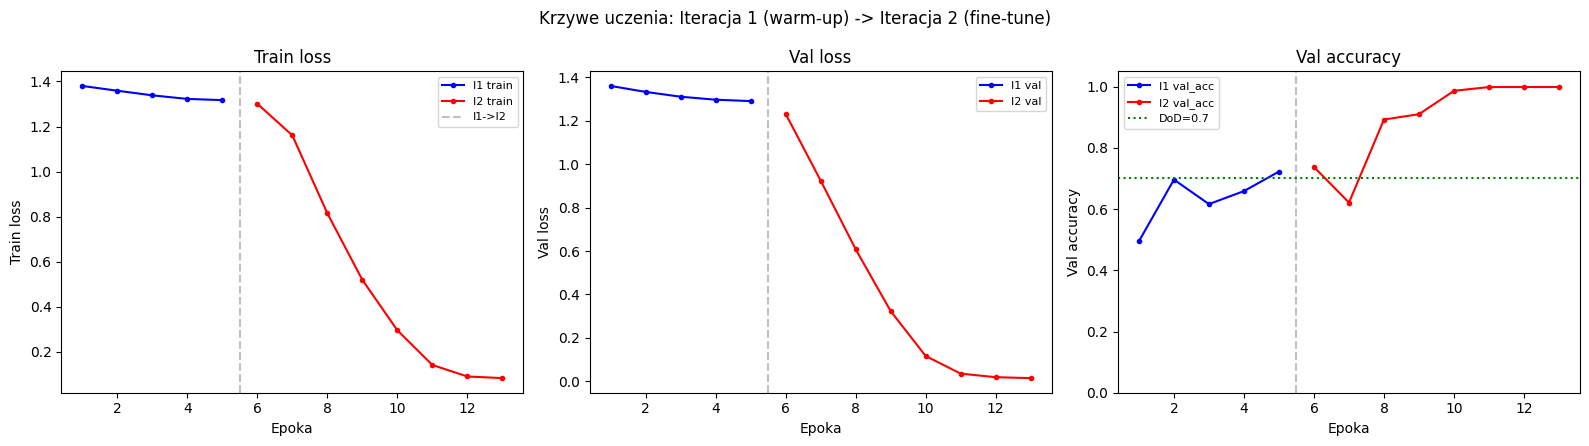

Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/learning_curves.png


In [52]:
plot_learning_curves(history_i1, history_i2,
    out_path=os.path.join(OUT_DIR, "learning_curves.png"), dod_line=0.70)

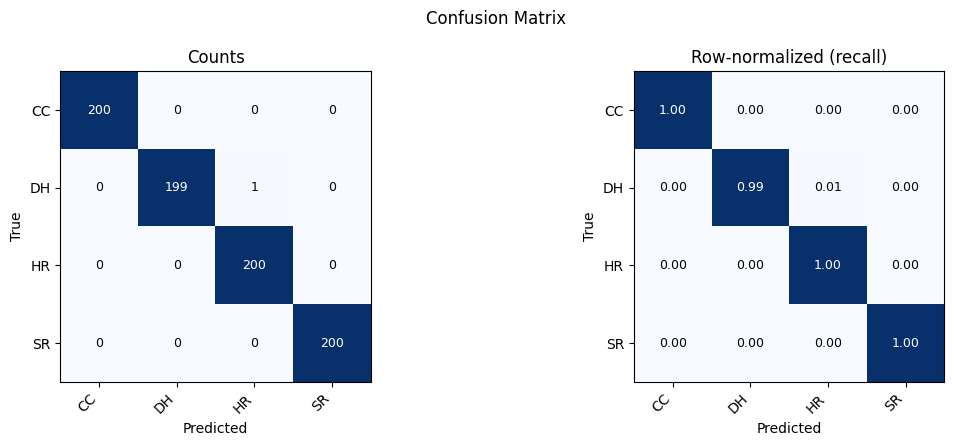

Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/confusion_matrix.png


In [53]:
plot_confusion_matrix(eval_i2['labels'], eval_i2['preds'], CLASSES,
    out_path=os.path.join(OUT_DIR, "confusion_matrix.png"))

In [54]:
save_classification_report(eval_i2['labels'], eval_i2['preds'], CLASSES,
    history_i1, history_i2, out_path=os.path.join(OUT_DIR, "classification_report.json"))

              precision    recall  f1-score   support

          CC       1.00      1.00      1.00       200
          DH       1.00      0.99      1.00       200
          HR       1.00      1.00      1.00       200
          SR       1.00      1.00      1.00       200

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/classification_report.json


FINAL EVAL na obu holdoutach (model tych obrazow NIGDY nie widzial)

--- Easy holdout (in-distribution, seed=123) ---
  Loss:     0.0480
  Accuracy: 0.9875


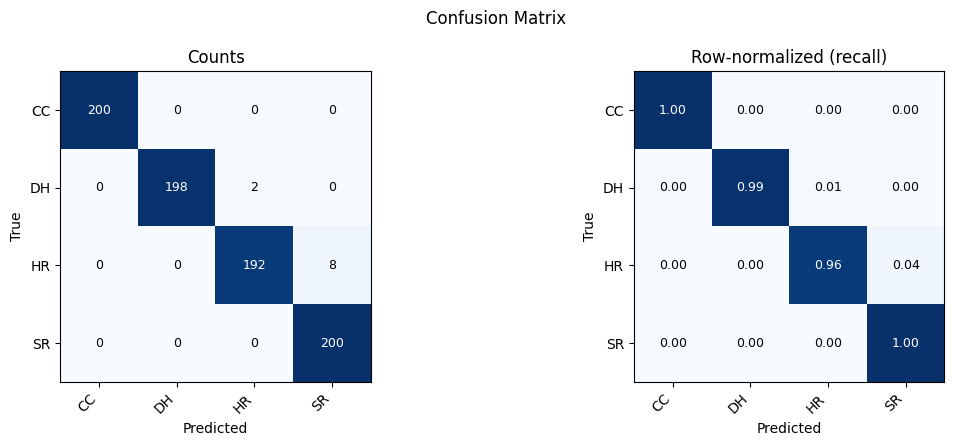

Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/confusion_matrix_holdout_easy.png

Classification report (holdout easy):
              precision    recall  f1-score   support

          CC       1.00      1.00      1.00       200
          DH       1.00      0.99      0.99       200
          HR       0.99      0.96      0.97       200
          SR       0.96      1.00      0.98       200

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800


--- Hard holdout (trudniejszy, OOD-like) ---
  Loss:     1.1115
  Accuracy: 0.6687


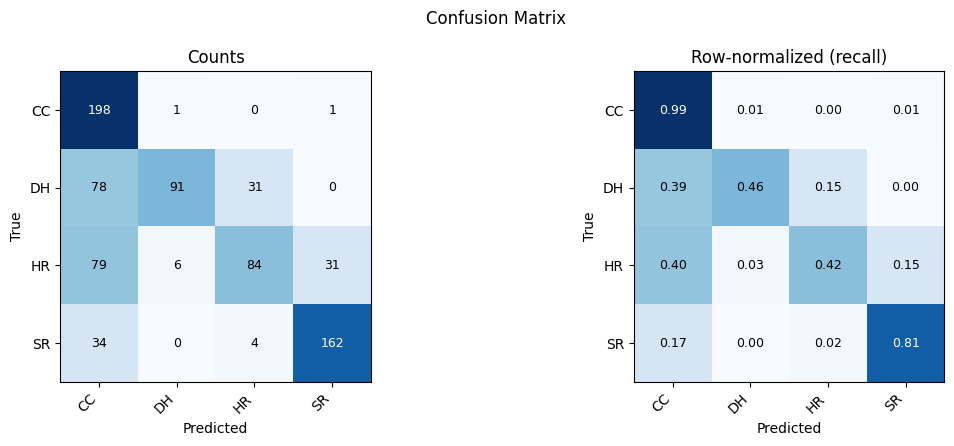

Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/confusion_matrix_holdout_hard.png

Classification report (holdout hard):
              precision    recall  f1-score   support

          CC       0.51      0.99      0.67       200
          DH       0.93      0.46      0.61       200
          HR       0.71      0.42      0.53       200
          SR       0.84      0.81      0.82       200

    accuracy                           0.67       800
   macro avg       0.74      0.67      0.66       800
weighted avg       0.74      0.67      0.66       800


Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/final_report.json

*** GLOWNE METRYKI DO PRACY KONCOWEJ ***
  Easy holdout: 0.9875
  Hard holdout: 0.6687
  Drop easy -> hard: 31.88 pp


In [55]:
# ===========================================================
# FINAL EVALUATION na obu holdoutach (raportowane w pracy koncowej)
# ===========================================================
# Model NIGDY nie widzial tych obrazow podczas treningu ani wyboru hyperparametrow.
# Hard holdout sluzy jako OOD-like test (trudniejsza dystrybucja niz easy).

from sklearn.metrics import classification_report

holdouts = [
    ('easy', holdout_loader, holdout_dataset, 123, "Easy holdout (in-distribution, seed=123)"),
    ('hard', holdout_hard_loader, holdout_hard_dataset, None, "Hard holdout (trudniejszy, OOD-like)"),
]

final_results = {
    'best_val_acc_i1': best_val_acc_i1,
    'best_val_acc_i2': best_val_acc_i2,
    'history_i1': history_i1,
    'history_i2': history_i2,
    'holdouts': {},
}

print("=" * 70)
print("FINAL EVAL na obu holdoutach (model tych obrazow NIGDY nie widzial)")
print("=" * 70)

for tag, loader, dataset, seed, desc in holdouts:
    print(f"\n--- {desc} ---")
    res = evaluate(model, loader, criterion, device)
    print(f"  Loss:     {res['loss']:.4f}")
    print(f"  Accuracy: {res['acc']:.4f}")

    # Confusion matrix per holdout
    plot_confusion_matrix(
        res['labels'], res['preds'], CLASSES,
        out_path=os.path.join(OUT_DIR, f"confusion_matrix_holdout_{tag}.png")
    )

    # Classification report
    print(f"\nClassification report (holdout {tag}):")
    report_dict = classification_report(res['labels'], res['preds'],
                                         target_names=CLASSES, output_dict=True)
    print(classification_report(res['labels'], res['preds'], target_names=CLASSES))

    # Do final raportu
    final_results['holdouts'][tag] = {
        'description': desc,
        'size': len(dataset),
        'seed': seed,
        'loss': res['loss'],
        'accuracy': res['acc'],
        'classification_report': report_dict,
    }

# Zapisz raport
report_path = os.path.join(OUT_DIR, "final_report.json")
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)
print(f"\nZapisano: {report_path}")

# Glowne metryki do raportowania (model card, praca koncowa)
final_holdout_easy_acc = final_results['holdouts']['easy']['accuracy']
final_holdout_hard_acc = final_results['holdouts']['hard']['accuracy']

print("\n" + "=" * 70)
print("*** GLOWNE METRYKI DO PRACY KONCOWEJ ***")
print(f"  Easy holdout: {final_holdout_easy_acc:.4f}")
print(f"  Hard holdout: {final_holdout_hard_acc:.4f}")
print(f"  Drop easy -> hard: {100 * (final_holdout_easy_acc - final_holdout_hard_acc):.2f} pp")
print("=" * 70)

## 10. Stress test -- robustness na degradacje obrazu

Sprawdzamy jak model trzyma sie przy zakloceniach test-time.
Cel: pokazac ze 0.99+ accuracy to efekt prostego syntetycznego datasetu --
model NIE jest magiczny, ma realny gradient degradacji.

In [56]:
def evaluate_stressed(model, base_dir, classes, transform_base, device,
                      noise_std=0.0, blur_radius=0.0, partial_mask=False):

    class StressedImageFolder(ImageFolder):
        def __init__(self, root, transform, ns, br, pm):
            super().__init__(root, transform=None)
            self.final_transform = transform
            self.ns, self.br, self.pm = ns, br, pm

        def __getitem__(self, index):
            path, target = self.samples[index]
            img = self.loader(path)
            if self.br > 0:
                img = img.filter(ImageFilter.GaussianBlur(radius=self.br))
            if self.ns > 0:
                arr = np.array(img).astype(np.float32)
                arr += np.random.randn(*arr.shape) * 255 * self.ns
                arr = np.clip(arr, 0, 255).astype(np.uint8)
                img = Image.fromarray(arr)
            if self.pm:
                arr = np.array(img).astype(np.float32)
                arr[arr.shape[0] // 2:, :] *= 0.15
                img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
            if self.final_transform:
                img = self.final_transform(img)
            return img, target

    ds = StressedImageFolder(base_dir, transform_base, noise_std, blur_radius, partial_mask)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

Stress test na OBU holdoutach -- accuracy przy degradacji obrazu:
--------------------------------------------------------------------------------

Holdout EASY:
  Clean (baseline)                     acc = 0.9875
  Mild noise (5%)                      acc = 0.9950
  Moderate (10% + blur 1)              acc = 0.9838
  Heavy (20% + blur 2)                 acc = 0.5887
  Partial image (dolna 1/2)            acc = 0.3962

Holdout HARD:
  Clean (baseline)                     acc = 0.6687
  Mild noise (5%)                      acc = 0.7875
  Moderate (10% + blur 1)              acc = 0.8425
  Heavy (20% + blur 2)                 acc = 0.3837
  Partial image (dolna 1/2)            acc = 0.3187


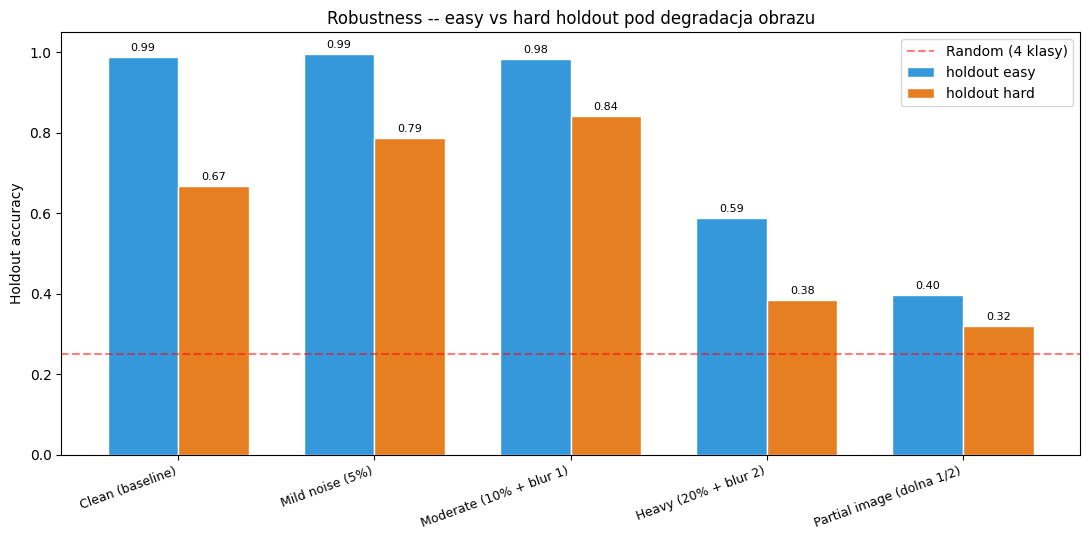


Zapisano: /content/run_02b_I2_unfreeze1blocks/outputs/stress_test_comparison.png


In [57]:
stress_configs = [
    {"name": "Clean (baseline)",          "noise_std": 0.00, "blur_radius": 0.0, "partial_mask": False},
    {"name": "Mild noise (5%)",           "noise_std": 0.05, "blur_radius": 0.0, "partial_mask": False},
    {"name": "Moderate (10% + blur 1)",   "noise_std": 0.10, "blur_radius": 1.0, "partial_mask": False},
    {"name": "Heavy (20% + blur 2)",      "noise_std": 0.20, "blur_radius": 2.0, "partial_mask": False},
    {"name": "Partial image (dolna 1/2)", "noise_std": 0.00, "blur_radius": 0.0, "partial_mask": True},
]

holdouts_for_stress = [
    ('easy', HOLDOUT_DIR,      '#3498db'),  # niebieski
    ('hard', HOLDOUT_HARD_DIR, '#e67e22'),  # pomaranczowy
]

# Liczymy accuracy dla kazdej (holdout, stress_config) kombinacji
print("Stress test na OBU holdoutach -- accuracy przy degradacji obrazu:")
print("-" * 80)
stress_results = {}
for ho_tag, ho_dir, _ in holdouts_for_stress:
    stress_results[ho_tag] = {}
    print(f"\nHoldout {ho_tag.upper()}:")
    for cfg in stress_configs:
        acc = evaluate_stressed(model, ho_dir, CLASSES, eval_transform, device,
            noise_std=cfg["noise_std"], blur_radius=cfg["blur_radius"],
            partial_mask=cfg["partial_mask"])
        stress_results[ho_tag][cfg["name"]] = acc
        print(f"  {cfg['name']:35s}  acc = {acc:.4f}")

# Wykres porownawczy: bary side-by-side dla easy vs hard
import numpy as np
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(stress_configs))
width = 0.36
names = [c["name"] for c in stress_configs]

for i, (ho_tag, _, color) in enumerate(holdouts_for_stress):
    accs = [stress_results[ho_tag][n] for n in names]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, accs, width, label=f"holdout {ho_tag}", color=color, edgecolor='white')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{acc:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.25, color='red', ls='--', alpha=0.5, label='Random (4 klasy)')
ax.set_ylabel('Holdout accuracy')
ax.set_title('Robustness -- easy vs hard holdout pod degradacja obrazu')
ax.legend()
plt.tight_layout()
stress_path = os.path.join(OUT_DIR, "stress_test_comparison.png")
plt.savefig(stress_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nZapisano: {stress_path}")

# Dolacz stress wyniki do final_report
final_results['stress_test'] = stress_results
with open(os.path.join(OUT_DIR, "final_report.json"), 'w', encoding='utf-8') as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

## 11. Upload na Hugging Face Model Hub

Pushujemy checkpoint + artefakty + model card. Po tym Drive nie jest potrzebny.

In [58]:
from huggingface_hub import login, whoami
from huggingface_hub.utils import LocalTokenNotFoundError

try:
    user_info = whoami()
    print(f"Zalogowany jako: {user_info['name']}")
except (LocalTokenNotFoundError, Exception):
    print("Brak tokena HF -- loguje...")
    login()
    user_info = whoami()
    print(f"Zalogowany jako: {user_info['name']}")

Zalogowany jako: koscielnamarta


In [59]:
from huggingface_hub import create_repo, upload_folder, upload_file

create_repo(MODEL_REPO, repo_type="model", exist_ok=True, private=False)
print(f"Model repo: https://huggingface.co/{MODEL_REPO}")

MODEL_CARD = f"""---
license: mit
tags:
  - ultrasound
  - veterinary
  - AFAST
  - tinyusfm
  - image-classification
library_name: pytorch
pipeline_tag: image-classification
datasets:
  - {DATASET_REPO}
metrics:
  - accuracy
  - f1
base_model: MacDunno/TinyUSFM
---

# TinyUSFM fine-tuned for synthetic veterinary AFAST classification

Two-stage transfer learning on [{DATASET_REPO}](https://huggingface.co/datasets/{DATASET_REPO}).

| Stage | Params | Best val_acc | Epochs | LR |
|---|---|---|---|---|
| I1 linear probing | {trainable_i1:,} ({100*trainable_i1/total_params:.1f}%) | {best_val_acc_i1:.4f} | {I1_EPOCHS} | {I1_LR} |
| I2 unfreeze {NUM_UNFROZEN_BLOCKS} blocks | {trainable_i2:,} ({100*trainable_i2/total_params:.1f}%) | {best_val_acc_i2:.4f} | {I2_EPOCHS} | {I2_LR} |

Trained exclusively on synthetic data -- not clinically usable.
Source: [github.com/koscielnamarta/vet-eye-ai-usg-demo](https://github.com/koscielnamarta/vet-eye-ai-usg-demo)
"""

with open("/tmp/model_card.md", "w", encoding="utf-8") as f:
    f.write(MODEL_CARD)

upload_file(path_or_fileobj="/tmp/model_card.md", path_in_repo="README.md",
            repo_id=MODEL_REPO, repo_type="model", commit_message="Add model card")
print("Model card uploaded")

Model repo: https://huggingface.co/koscielnamarta/synthetic-usg-afast-vet-classifier
Model card uploaded


In [60]:
print(f"Uploaduje: {RUN_DIR}")
for root, dirs, files in os.walk(RUN_DIR):
    for fn in files:
        fp = os.path.join(root, fn)
        rel = os.path.relpath(fp, RUN_DIR)
        sz = os.path.getsize(fp)
        print(f"  {rel} ({sz/1e3:.0f} kB)" if sz < 1e6 else f"  {rel} ({sz/1e6:.1f} MB)")

upload_folder(folder_path=RUN_DIR, repo_id=MODEL_REPO, repo_type="model",
    ignore_patterns=["*.tmp", "__pycache__/*", "best_i1.pt"],
    commit_message=f"Upload best checkpoint + artifacts (val_acc {best_val_acc:.4f})")
print(f"\nDone! https://huggingface.co/{MODEL_REPO}")

Uploaduje: /content/run_02b_I2_unfreeze1blocks
  outputs/confusion_matrix_holdout_easy.png (45 kB)
  outputs/learning_curves.png (95 kB)
  outputs/confusion_matrix.png (42 kB)
  outputs/confusion_matrix_holdout_hard.png (52 kB)
  outputs/classification_report.json (2 kB)
  outputs/stress_test_comparison.png (88 kB)
  outputs/final_report.json (4 kB)
  checkpoints/best_i2.pt (22.2 MB)
  checkpoints/best_i1.pt (22.2 MB)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ks/checkpoints/best_i2.pt:  92%|#########1| 20.3MB / 22.2MB            

  ...ks/checkpoints/best_i1.pt: 100%|#########9| 22.1MB / 22.2MB            


Done! https://huggingface.co/koscielnamarta/synthetic-usg-afast-vet-classifier


## 12. Pobranie artefaktow (do commit na GitHub)

In [61]:
zip_path = f"/content/artefakty_02b_{RUN_NAME}.zip"
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', OUT_DIR)
print(f"ZIP: {zip_path} ({os.path.getsize(zip_path)/1e3:.0f} kB)")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Nie w Colabie -- pobierz recznie:", zip_path)

ZIP: /content/artefakty_02b_I2_unfreeze1blocks.zip (274 kB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>